In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import pandas as pd
import yfinance as yf
from pathlib import Path
import logging
import sys
from pathlib import Path
from bcb import sgs


In [26]:
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = RAIZ / "data" / "raw"
DATA = RAIZ / "data"
sys.path.insert(0, str(RAIZ / "src"))

from moq import data

# sem isso os log.warning de dentro do moq não aparecem formatados
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s", force=True)

print("raiz:", RAIZ)

raiz: /home/marialuisa/finance/mini-open-quant


foram excluídos os TICKERS : 'JBSS3.SA', 'EMBR3.SA', 'ELET3.SA' , porque eles não foram encontrados durante toda a janela de tempo, provavelmente saíram da listagem da bolsa.

A data inicial de 01/01/2012 foi escolhida, pois representa um período de volatilidade política e econômica no Brasil. De 2012 - 2015 o Brasil passou por um período de expansão e crescimento. Em 2015, teve a Operação Lava-Jato, o que causou uma forte crise econômica e o mercado ficou instável. Também consideramos o período da pandemia, até o período atual.

In [27]:
TICKERS = ["PETR4","PETR3","VALE3","ITUB4","BBDC4","BBAS3","ABEV3","WEGE3",
           "B3SA3","RENT3","SUZB3","PRIO3","RADL3","EQTL3","BPAC11",
           "ITSA4","LREN3","HAPV3","GGBR4","RAIL3","VIVT3","CSAN3",
           "TOTS3","CMIG4","BBSE3","ENEV3","SBSP3"]

raw = yf.download([t + ".SA" for t in TICKERS], start="2012-01-01", auto_adjust=True, progress=False)

prices = raw["Close"].copy()
prices.columns = [c.replace(".SA", "") for c in prices.columns]
prices.index = pd.DatetimeIndex(prices.index).tz_localize(None)
prices.shape

# ['JBSS3.SA', 'EMBR3.SA', 'ELET3.SA']: possibly delisted; no timezone found - foram removidas

(3654, 27)

<Axes: title={'center': 'Quantos ativos sem preço, por dia'}, xlabel='Date'>

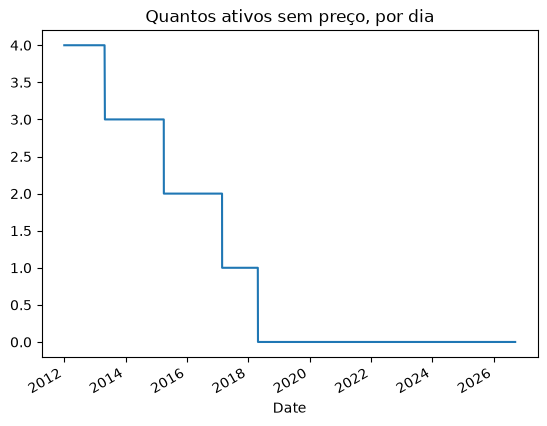

In [28]:
prices.isna().sum(axis=1).plot(title="Quantos ativos sem preço, por dia")

In [29]:
cdi = data.fetch_cdi("2012-01-01")
#print(cdi.head())
#print("período:", cdi.index.min().date(), "→", cdi.index.max().date(), "| dias:", len(cdi))

ano = cdi["2023"]
acumulado = (1 + ano).prod() - 1
print(f"\nCDI acumulado em 2023: {acumulado:.2%}")

INFO httpx: HTTP Request: GET https://api.bcb.gov.br/dados/serie/bcdata.sgs.12/dados?formato=json&dataInicial=01%2F01%2F2012&dataFinal=31%2F12%2F2016 "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: GET https://api.bcb.gov.br/dados/serie/bcdata.sgs.12/dados?formato=json&dataInicial=01%2F01%2F2017&dataFinal=31%2F12%2F2021 "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: GET https://api.bcb.gov.br/dados/serie/bcdata.sgs.12/dados?formato=json&dataInicial=01%2F01%2F2022&dataFinal=15%2F09%2F2026 "HTTP/1.1 200 OK"



CDI acumulado em 2023: 13.04%


<Axes: title={'center': 'Fator de mercado NEFIN acumulado'}, xlabel='Date'>

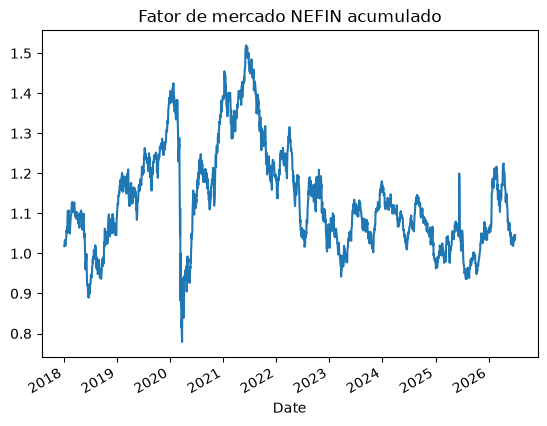

In [30]:
def ler_fatores(caminho):
    df = pd.read_csv(caminho, index_col=0)  # 1ª coluna é só um contador
    df.index = pd.to_datetime(df["Date"])
    df.index.name = "Date"
    return df[["Rm_minus_Rf", "SMB", "HML", "WML"]].rename(columns={"Rm_minus_Rf": "MKT"})

fatores = ler_fatores(RAW / "nefin" / "nefin_factors.csv")
(1 + fatores["MKT"]["2018":]).cumprod().plot(title="Fator de mercado NEFIN acumulado")